In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import pandas as pd

df = pd.read_csv("../../dataset/06_model_dataset/model_data.csv")
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(scale_pos_weight)

# 🔥 IMPORTANT: create eval set
eval_set = [(X_train, y_train), (X_test, y_test)]

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss"   # needed for loss curve
)

model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)

7.990685191032523


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

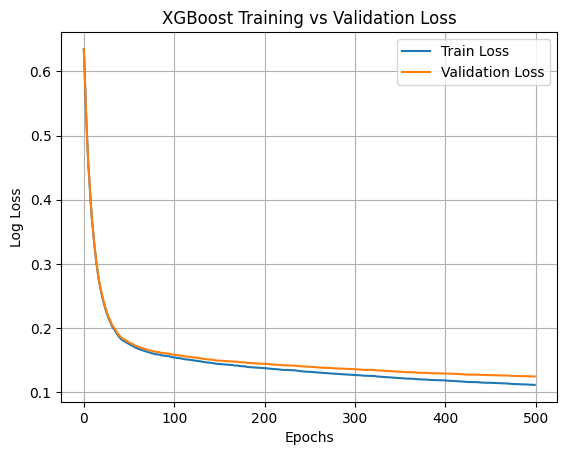

In [145]:
results = model.evals_result()
import matplotlib.pyplot as plt

epochs = len(results['validation_0']['logloss'])
x_axis = range(epochs)

plt.plot(x_axis, results['validation_0']['logloss'], label='Train Loss')
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation Loss')

plt.title('XGBoost Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.legend()
plt.grid()
plt.show()

In [146]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# F1 = harmonic mean of precision and recall — best single metric for imbalanced classification
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (maximises F1): {best_threshold:.4f}")
print(f"Best F1 Score: {f1_scores[best_idx]:.4f}")

Best Threshold (maximises F1): 0.8285
Best F1 Score: 0.8557


In [147]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

y_prob = model.predict_proba(X_test)[:, 1]

# Adjust threshold based on business need:
# Lower → catch more churners (higher recall, more false alarms)
# Higher → fewer false alarms (higher precision, miss more churners)
threshold = 0.821

y_pred = (y_prob > threshold).astype(int)

print(f"Threshold used: {threshold}")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))



# SAVE AS TABLE
# Convert X_test to DataFrame (if it's not already)
X_test_df = pd.DataFrame(X_test)

# Create results table
results_df = X_test_df.copy()
results_df['y_actual'] = y_test.values
results_df['y_pred'] = y_pred
results_df['y_prob'] = y_prob

counts = results_df.groupby(['y_actual', 'y_pred']).size()

print("0 → 0 :", counts.get((0, 0), 0))
print("1 → 1 :", counts.get((1, 1), 0))
print("0 → 1 :", counts.get((0, 1), 0))
print("1 → 0 :", counts.get((1, 0), 0))

matched = (results_df['y_actual'] == results_df['y_pred']).sum()
unmatched = (results_df['y_actual'] != results_df['y_pred']).sum()

print("Matched:", matched)
print("Unmatched:", unmatched)

print(results_df['y_actual'] , "====>" , results_df['y_pred'] , "==" , results_df['y_prob'])
print()

results_df.to_csv("../../dataset/07_powerbi/bi_prediction.csv")




Threshold used: 0.821
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     20245
           1       0.87      0.84      0.85      2534

    accuracy                           0.97     22779
   macro avg       0.92      0.91      0.92     22779
weighted avg       0.97      0.97      0.97     22779

ROC AUC: 0.9880877755778998
0 → 0 : 19918
1 → 1 : 2135
0 → 1 : 327
1 → 0 : 399
Matched: 22053
Unmatched: 726
99167     0
23295     0
58634     0
44660     1
59460     0
         ..
8444      0
52708     0
51505     0
21249     0
107433    0
Name: y_actual, Length: 22779, dtype: int64 ====> 99167     0
23295     0
58634     0
44660     1
59460     0
         ..
8444      0
52708     0
51505     0
21249     0
107433    0
Name: y_pred, Length: 22779, dtype: int32 == 99167     0.005837
23295     0.016809
58634     0.272865
44660     0.893538
59460     0.001680
            ...   
8444      0.013404
52708     0.002250
51505     0.016572
21249     0.

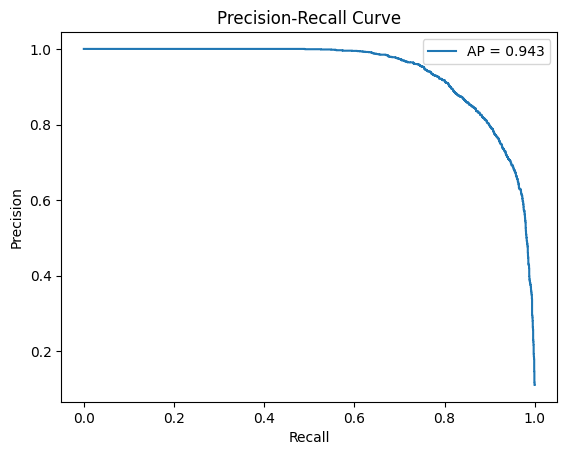

In [148]:
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

ap_score = average_precision_score(y_test, y_prob)

plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [149]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1 = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1:", f1[best_idx])

Best Threshold: 0.8284756
Best F1: 0.8557053728147487


In [150]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Convert to table format
cm_df = pd.DataFrame(cm, 
                     index=['Actual_0', 'Actual_1'], 
                     columns=['Pred_0', 'Pred_1'])

# Save
cm_df.to_csv("../../dataset/07_powerbi/confusion_matrix.csv")

In [151]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_df = pd.DataFrame({
    'FPR': fpr,
    'TPR': tpr,
    'Threshold': thresholds
})

roc_df.to_csv("../../dataset/07_powerbi/roc_curve.csv", index=False)

In [152]:
auc_value = roc_auc_score(y_test, y_prob)

auc_df = pd.DataFrame({
    'Metric': ['ROC_AUC'],
    'Value': [auc_value]
})

print(auc_value)

auc_df.to_csv("../../dataset/07_powerbi/auc_score.csv", index=False)

0.9880877755778998


In [153]:
# sample_non_churn_full = {
#  'Discount_Amount': 0.0, 'Sustainability_Score': 9.5, 'Auto_Renewal_Score': 9,
#  'Status_Scores': 9, 'Anchoring_Score': 9.0, 'Proforma_Auto_Renewal': 0,
#  'Current_Anchorings': 2, 'Payment_Timeframe': 0.0, 'Current_Auto_Renewal_Flag': 1,
#  'Current_World_Pay_Token': 1, 'Renewal_Score_At_Release': 27.0, 'Tenure_Years': 5,
#  'Total_Net_Paid': 700, 'Serious_Complaint_renewal': 0,
#  'Renewal_Impact_Due_to_Price_Increase_renewal': 0, 'Call_Reschedule_Request_renewal': 0,
#  'Explicit_Competitor_Mention_renewal': 0, 'Price_Switching_Mentioned_renewal': 0,
#  'Explicit_Switching_Intent_flag': 0, 'Discount_Offered_flag': 0,
#  'Customer_Response_flag': 0, 'cancel_flag': 0, 'Call_attend_status_renewal': 1,
#  'competitor_mentioned_flag': 0, 'topic_customer_flag': 0,
#  'stage_high_risk_flag': 0, 'stage_low_risk_flag': 1, 'agent_complaint_flag': 0,
#  'Band_Band B': 0, 'Band_Band C1': 0, 'Band_Band C2': 0, 'Band_Band D': 1,
#  'Band_Band E': 0, 'Band_Band F': 0, 'Band_Band F1': 0, 'Band_Band F2': 0,
#  'Band_Band G': 0, 'Band_Band H': 0, 'Band_Band I': 0, 'Band_Band J': 0,
#  'Band_Group': 0, 'Band_Unknown': 0,
#  'Connection_Group_10+': 0, 'Connection_Group_2': 0, 'Connection_Group_3': 1,
#  'Connection_Group_4-9': 0, 'Connection_Group_Unknown': 0, 'Connection_Group_independent': 0,
#  'Tenure_Group_2': 0, 'Tenure_Group_3': 0, 'Tenure_Group_4+': 1, 'Tenure_Group_Unknown': 0,
#  'Anchor_Group_10+': 0, 'Anchor_Group_2': 0, 'Anchor_Group_3': 1,
#  'Anchor_Group_4-9': 0, 'Anchor_Group_Unknown': 0, 'Anchor_Group_independent': 0,
#  'Competitor_Value_Comparison_renewal_not discussed': 0,
#  'Competitor_Value_Comparison_renewal_similar value': 0,
#  'Competitor_Value_Comparison_renewal_unknown': 1,
#  'Customer_Response_Risk_Low Risk': 1, 'Customer_Response_Risk_Medium Risk': 0,
#  'Customer_Response_Risk_Neutral': 0
# }

# sample_churn_strong = {
#  'Discount_Amount': 50.0, 'Sustainability_Score': 6.0, 'Auto_Renewal_Score': 5,
#  'Status_Scores': 0, 'Anchoring_Score': 6.5, 'Proforma_Auto_Renewal': 0,
#  'Current_Anchorings': 0, 'Payment_Timeframe': 5.0, 'Current_Auto_Renewal_Flag': 0,
#  'Current_World_Pay_Token': 0, 'Renewal_Score_At_Release': 20.0, 'Tenure_Years': 1,
#  'Total_Net_Paid': 200, 'Serious_Complaint_renewal': 1,
#  'Renewal_Impact_Due_to_Price_Increase_renewal': 1, 'Call_Reschedule_Request_renewal': 1,
#  'Explicit_Competitor_Mention_renewal': 1, 'Price_Switching_Mentioned_renewal': 1,
#  'Explicit_Switching_Intent_flag': 1, 'Discount_Offered_flag': 1,
#  'Customer_Response_flag': 1, 'cancel_flag': 0, 'Call_attend_status_renewal': 0,
#  'competitor_mentioned_flag': 1, 'topic_customer_flag': 1,
#  'stage_high_risk_flag': 1, 'stage_low_risk_flag': 0, 'agent_complaint_flag': 1,
#  'Band_Band B': 0, 'Band_Band C1': 1, 'Band_Band C2': 0, 'Band_Band D': 0,
#  'Band_Band E': 0, 'Band_Band F': 0, 'Band_Band F1': 0, 'Band_Band F2': 0,
#  'Band_Band G': 0, 'Band_Band H': 0, 'Band_Band I': 0, 'Band_Band J': 0,
#  'Band_Group': 0, 'Band_Unknown': 0,
#  'Connection_Group_10+': 0, 'Connection_Group_2': 1, 'Connection_Group_3': 0,
#  'Connection_Group_4-9': 0, 'Connection_Group_Unknown': 0, 'Connection_Group_independent': 0,
#  'Tenure_Group_2': 1, 'Tenure_Group_3': 0, 'Tenure_Group_4+': 0, 'Tenure_Group_Unknown': 0,
#  'Anchor_Group_10+': 0, 'Anchor_Group_2': 1, 'Anchor_Group_3': 0,
#  'Anchor_Group_4-9': 0, 'Anchor_Group_Unknown': 0, 'Anchor_Group_independent': 0,
#  'Competitor_Value_Comparison_renewal_not discussed': 0,
#  'Competitor_Value_Comparison_renewal_similar value': 1,
#  'Competitor_Value_Comparison_renewal_unknown': 0,
#  'Customer_Response_Risk_Low Risk': 0, 'Customer_Response_Risk_Medium Risk': 1,
#  'Customer_Response_Risk_Neutral': 0
# }

# test_df = pd.DataFrame([sample_non_churn_full, sample_churn_strong])
# test_df.index = ['Non-Churn Example', 'Strong Churn Example']

# preds = model.predict(test_df)
# probs = model.predict_proba(test_df)[:, 1]

# test_df['prediction'] = preds
# test_df['churn_probability'] = probs

# print(test_df[['prediction', 'churn_probability']])

Top 20 Feature Importances:
Status_Scores                                  0.362977
Current_World_Pay_Token                        0.123954
Sustainability_Score                           0.062934
stage_high_risk_flag                           0.025941
Auto_Renewal_Score                             0.024178
Anchor_Group_Unknown                           0.023964
Connection_Group_Unknown                       0.022442
Total_Net_Paid                                 0.022148
cancel_flag                                    0.021994
Current_Auto_Renewal_Flag                      0.021450
Band_Unknown                                   0.019092
Tenure_Years                                   0.018774
Discount_Amount                                0.017476
Band_Band B                                    0.015726
Band_Band F                                    0.013604
Payment_Timeframe                              0.009816
Renewal_Score_At_Release                       0.009495
Tenure_Group_3      

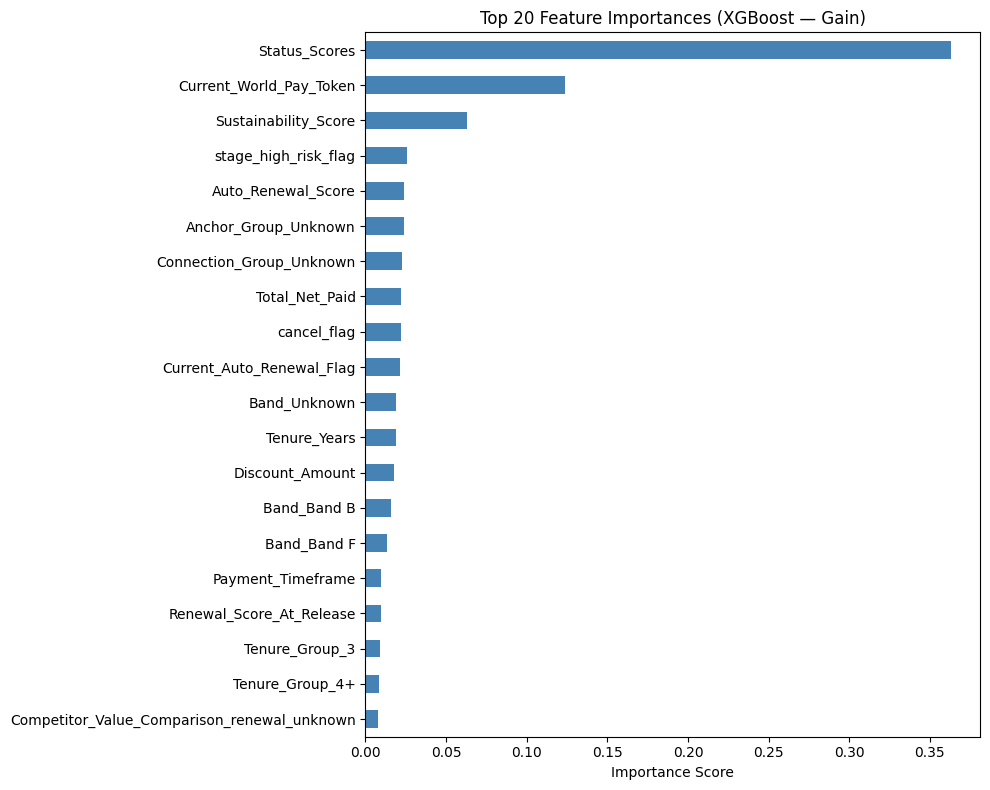

In [154]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(20)

print("Top 20 Feature Importances:")
print(top_features)

plt.figure(figsize=(10, 8))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 20 Feature Importances (XGBoost — Gain)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# SAVE AS TABLE


# Convert Series to DataFrame
feature_importance_df = top_features.reset_index()

# Rename columns
feature_importance_df.columns = ['Feature', 'Importance']

# Save to CSV
feature_importance_df.to_csv("../../dataset/07_powerbi/feature_importance.csv", index=False)

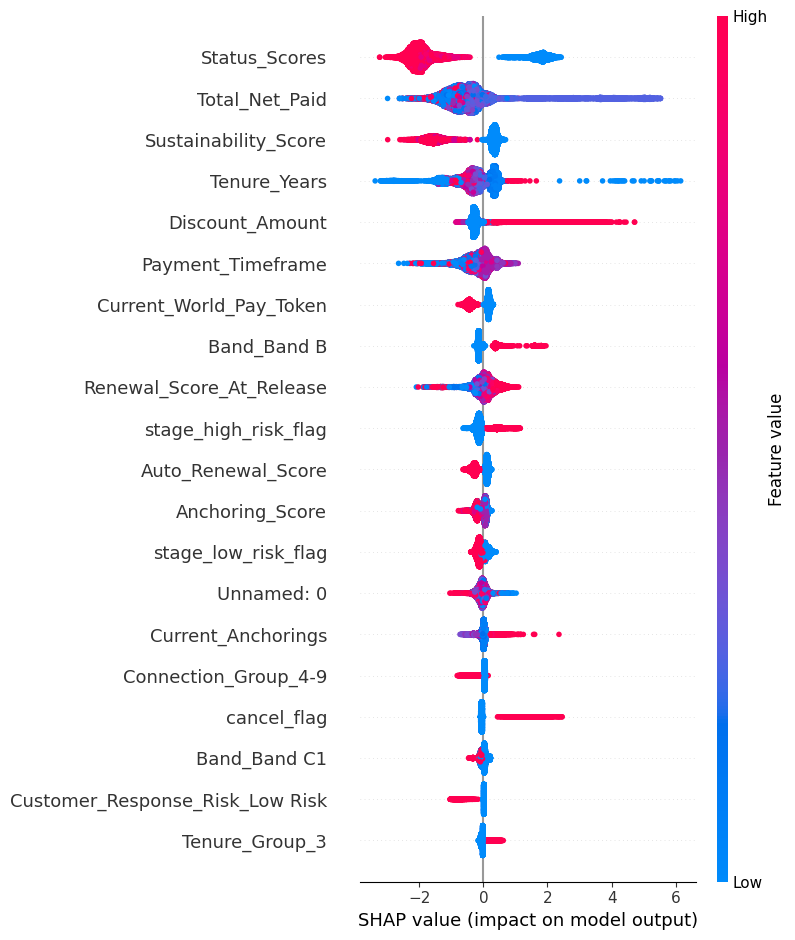

SHAP datasets saved successfully 🚀


In [155]:
# =========================
# SHAP EXPLAINABILITY
# =========================
import shap
import pandas as pd
import numpy as np

# -------------------------
# 1. Create SHAP Explainer
# -------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)



# =========================
# 2. GLOBAL SHAP IMPORTANCE
# =========================
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by='SHAP_Importance', ascending=False
)

# Save
shap_importance.to_csv(
    "../../dataset/07_powerbi/shap_feature_importance.csv",
    index=False
)

# =========================
# 3. ROW-LEVEL SHAP TABLE
# =========================
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# Add prediction info
shap_df['y_actual'] = y_test.values
shap_df['y_pred'] = y_pred
shap_df['y_prob'] = y_prob
shap_df['threshold'] = best_threshold

# Save
shap_df.to_csv(
    "../../dataset/07_powerbi/shap_row_level.csv",
    index=False
)

# =========================
# 4. TOP FEATURES PER ROW
# =========================
def get_top_features(row, top_n=3):
    return list(row.abs().sort_values(ascending=False).head(top_n).index)

shap_df['top_3_features'] = shap_df[X_test.columns].apply(get_top_features, axis=1)

# Save compact table
top_features_df = shap_df[['y_actual', 'y_pred', 'y_prob', 'top_3_features']]

top_features_df.to_csv(
    "../../dataset/07_powerbi/shap_top_features.csv",
    index=False
)

# =========================
# 5. OPTIONAL VISUALS
# =========================
# Global summary plot
shap.summary_plot(shap_values, X_test)

# Individual explanation (first row)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

print("SHAP datasets saved successfully 🚀")

In [156]:
# pip install llvmlite==0.41.1
# pip install numba==0.58.1
# pip install shap==0.44.1

In [157]:

import xgboost
print(xgboost.__version__)

3.2.0


In [158]:

import numpy
print(numpy.__version__)

1.26.4
